Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


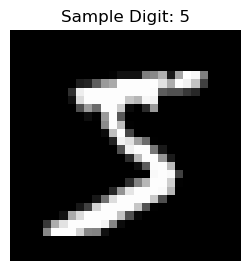

Validation Accuracy: 97.01%
Test Accuracy: 96.97%

Confusion Matrix:
[[ 968    0    3    1    0    2    3    1    2    0]
 [   0 1125    3    0    0    1    3    1    2    0]
 [   5    2 1000    2    1    0    2   12    7    1]
 [   0    0    4  983    1    6    0    8    8    0]
 [   1    0    9    0  951    1    3    8    1    8]
 [   3    0    3   11    2  857    5    7    3    1]
 [   2    2    2    0    4   10  930    3    5    0]
 [   0    4   11    2    3    1    0  996    1   10]
 [   2    0    5    7    5    8    1   10  931    5]
 [   1    3    5   11    9    4    0   17    3  956]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.96      0.96       8

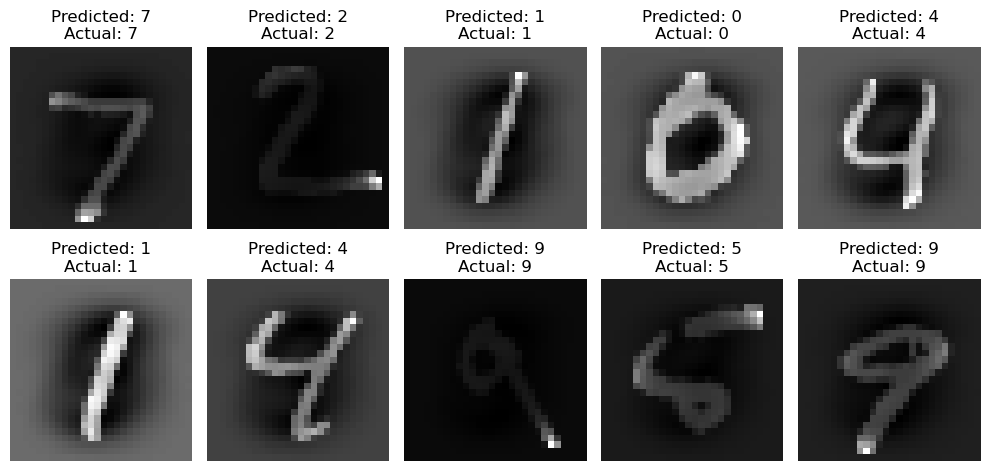

In [6]:
#%% 
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#%%
# Load the MNIST handwritten digits dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

#%%
# Visualize one sample image
plt.figure(figsize=(3,3))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Sample Digit: {y_train[0]}")
plt.axis('off')
plt.show()

#%%
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Split training set further into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

#%%
# Normalize the data for better SVM performance
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

#%%
# Create and train the SVM model (RBF kernel gives good accuracy)
svm_model = SVC(kernel='rbf', C=5, gamma='scale')
svm_model.fit(x_train, y_train)

#%%
# Predict on validation set
y_val_pred = svm_model.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

#%%
# Predict on test set
y_test_pred = svm_model.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

#%%
# Display performance metrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

#%%
# Visualize some test predictions
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {y_test_pred[i]}\nActual: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
